In [1]:
import numpy as np
import tensorflow as tf
import torch
from tensorflow.keras.models import load_model
from tensorflow.keras import Model, layers, Input
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load pretrained CNN model
pretrained_model = load_model("best_model_wood_92%.h5")

In [3]:
pretrained_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d (Conv3D)             (None, 30, 30, 197, 32)   896       
                                                                 
 average_pooling3d (AverageP  (None, 15, 15, 98, 32)   0         
 ooling3D)                                                       
                                                                 
 conv3d_1 (Conv3D)           (None, 13, 13, 96, 64)    55360     
                                                                 
 conv3d_2 (Conv3D)           (None, 11, 11, 94, 128)   221312    
                                                                 
 average_pooling3d_1 (Averag  (None, 5, 5, 47, 128)    0         
 ePooling3D)                                                     
                                                                 
 flatten (Flatten)           (None, 150400)            0

In [4]:
#Load label embeddings
word_embeddings = np.load("wood_no_desc.npy", allow_pickle=True).item()  # Dictionary with keys

# Extract embeddings and stack into a 2D array
word_embeddings = np.stack([word_embeddings['heartwood'], 
                                   word_embeddings['sapwood']])  # Convert tensors to numpy arrays

# Ensure word_embeddings is a Tensor
word_embeddings_tensor = tf.convert_to_tensor(word_embeddings, dtype=tf.float32)

In [5]:
word_embeddings_tensor.shape

TensorShape([2, 300])

In [5]:
'''
# Load the saved embeddings
word_embeddings = np.load("Wood_embeddings_sentence.npy", allow_pickle=True).item()

word_embeddings = np.stack([
    word_embeddings['heartwood'],
    word_embeddings['sapwood']     
])

# Convert to TensorFlow tensor if needed
word_embeddings_tensor = tf.convert_to_tensor(word_embeddings, dtype=tf.float32)
'''

In [6]:
# Freeze the pretrained layers
for layer in pretrained_model.layers:
    
    layer.trainable = False

# Get the third-last layer's output
second_last_layer_output = pretrained_model.get_layer(index = -4).output  # Shape: (None, 128)

# Define a new trainable dense layer with X neurons
dense_layer = layers.Dense(300, activation='relu', name="trainable_dense_layer")(second_last_layer_output)  # Shape: (None, 1024)

# Compute the dot product with word embeddings
dot_product = tf.matmul(dense_layer, tf.transpose(word_embeddings_tensor))  # Shape: (None, 2)

# Apply softmax activation to get predictions
predictions = layers.Softmax(name="softmax_predictions")(dot_product)

In [7]:
# Define the new model
new_model = Model(inputs=pretrained_model.input, outputs=predictions)

# Compile the model for training
new_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Summary of the new model
new_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d_input (InputLayer)   [(None, 32, 32, 199, 1)]  0         
                                                                 
 conv3d (Conv3D)             (None, 30, 30, 197, 32)   896       
                                                                 
 average_pooling3d (AverageP  (None, 15, 15, 98, 32)   0         
 ooling3D)                                                       
                                                                 
 conv3d_1 (Conv3D)           (None, 13, 13, 96, 64)    55360     
                                                                 
 conv3d_2 (Conv3D)           (None, 11, 11, 94, 128)   221312    
                                                                 
 average_pooling3d_1 (Averag  (None, 5, 5, 47, 128)    0         
 ePooling3D)                                                 

In [2]:
# Load PCA data and labels
data_train = np.load('Wood_data_train_PCA.npy')
data_test = np.load('Wood_data_test_PCA.npy')

train_labels = np.load('Wood_train_labels.npy', allow_pickle=True)
test_labels = np.load('Wood_test_labels.npy', allow_pickle=True)

print(data_train.shape, data_test.shape, train_labels.shape, test_labels.shape )

(264, 32, 32, 199, 1) (132, 32, 32, 199, 1) (264,) (132,)


In [3]:
le = LabelEncoder()

y_train = le.fit_transform(train_labels)
y_test = le.transform(test_labels) 

In [10]:
# Train the model
history = new_model.fit(
    
    data_train,           
    y_train,      
    epochs = 50,           
    batch_size = 4,     
    validation_data=(data_test, y_test),  
    
    callbacks=[     
               
        tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('best_model_merged_w2v.h5', save_best_only=True)
    ]
)

Epoch 1/50
66/66 [==============================] - 5s 34ms/step - loss: 0.4608 - accuracy: 0.9659 - val_loss: 0.3832 - val_accuracy: 0.9470
Epoch 2/50
66/66 [==============================] - 2s 30ms/step - loss: 0.3065 - accuracy: 0.9735 - val_loss: 0.3635 - val_accuracy: 0.9470
Epoch 3/50
66/66 [==============================] - 2s 27ms/step - loss: 0.2617 - accuracy: 0.9735 - val_loss: 0.3678 - val_accuracy: 0.9470
Epoch 4/50
66/66 [==============================] - 2s 27ms/step - loss: 0.2390 - accuracy: 0.9773 - val_loss: 0.3775 - val_accuracy: 0.9470
Epoch 5/50
66/66 [==============================] - 2s 27ms/step - loss: 0.2259 - accuracy: 0.9773 - val_loss: 0.3895 - val_accuracy: 0.9470
Epoch 6/50
66/66 [==============================] - 2s 27ms/step - loss: 0.2166 - accuracy: 0.9811 - val_loss: 0.4018 - val_accuracy: 0.9470
Epoch 7/50
66/66 [==============================] - 2s 27ms/step - loss: 0.2104 - accuracy: 0.9811 - val_loss: 0.4146 - val_accuracy: 0.9470
Epoch 8/50
66

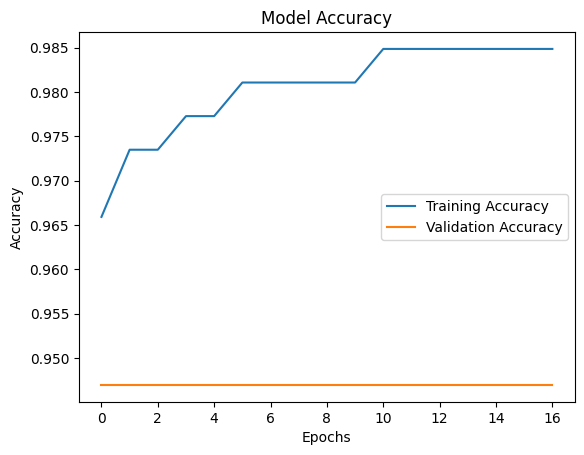

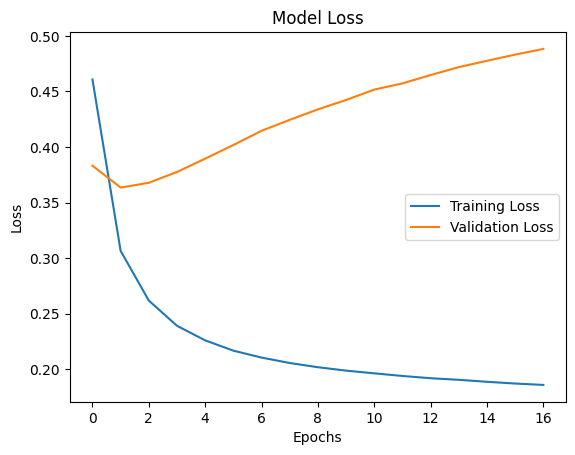

In [12]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [6]:
new_model = load_model('best_model_merged_roberta_no_desc.h5')

In [7]:
# Evaluate the model
test_loss, test_accuracy = new_model.evaluate(data_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

5/5 [==============================] - 3s 115ms/step - loss: 0.8564 - accuracy: 0.9394
Test Loss: 0.8564
Test Accuracy: 0.9394


In [8]:
# Predict class probabilities for the test set
test_predictions_prob = new_model.predict(data_test)

# Convert probabilities to predicted class labels
test_predictions = np.argmax(test_predictions_prob, axis=1)

5/5 [==============================] - 1s 149ms/step


In [9]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, test_predictions, target_names=["Heartwood", "Sapwood"], digits=4))

Classification Report:
              precision    recall  f1-score   support

   Heartwood     0.9833    0.8939    0.9365        66
     Sapwood     0.9028    0.9848    0.9420        66

    accuracy                         0.9394       132
   macro avg     0.9431    0.9394    0.9393       132
weighted avg     0.9431    0.9394    0.9393       132



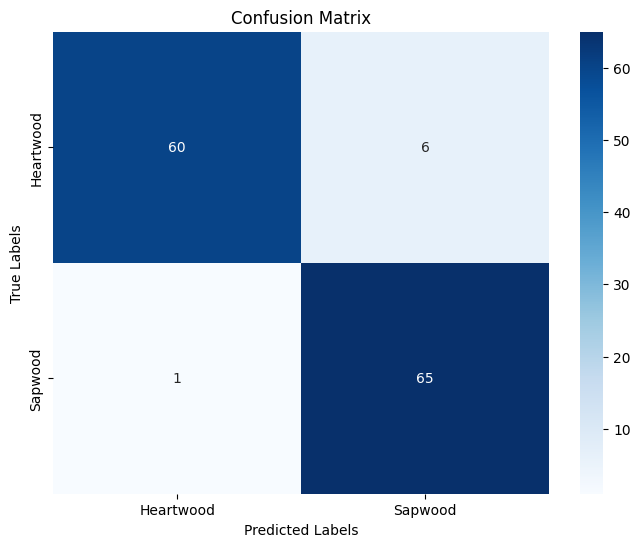

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Heartwood", "Sapwood"], yticklabels=["Heartwood", "Sapwood"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()